In [1]:
# General
import os
import keras
import numpy as np
import pandas as pd
import tensorflow as tf

# Data
import plotly.express as px
import matplotlib.pyplot as plt

# Data Preprocessing
import tensorflow.data as tfds
from sklearn.model_selection import train_test_split

# Model
from keras.applications import VGG16
from keras.applications import Xception, InceptionV3
from keras.applications import ResNet50V2, ResNet152V2
from keras.applications import MobileNetV3Small, MobileNetV3Large

# Model training
from keras import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten, GlobalAveragePooling2D
from keras.layers import InputLayer

# Model Callbacks
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [2]:
# Setting constants for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Constants
BATCH_SIZE = 32
IMAGE_SIZE = 224

Total valid images  : 23,708
Sample Image path   : 9_0_0_20170120133313910.jpg.chip.jpg
Sample Age          : 9
Sample Gender       : Male


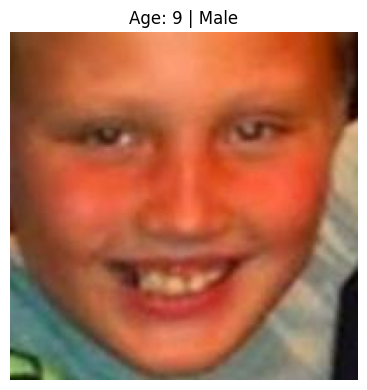

In [ ]:

# LOCAL path
dir_path = r"D:\Age-and-Gender-Detection-From-Face-Image\archive\UTKFace"
# ─────────────────────────────────────────────────────────────────────────────

# ✅ Safety check (very important)
if not os.path.exists(dir_path):
    raise FileNotFoundError(f"Dataset path not found: {dir_path}")

# Gender label mapping
gender_mapping = ["Male", "Female"]

# Load all image file names
image_paths = os.listdir(dir_path)

# Filter valid filenames
valid_paths = []
for p in image_paths:
    parts = p.split("_")
    if len(parts) >= 2:
        try:
            int(parts[0])  # age
            int(parts[1])  # gender
            valid_paths.append(p)
        except ValueError:
            continue

image_paths = valid_paths

print(f"Total valid images  : {len(image_paths):,}")

# ─── RANDOM SAMPLE ────────────────────────────────────────────────────────────
rand_image_path = np.random.choice(image_paths)

# FIX: use os.path.join (not +)
img_full_path = os.path.join(dir_path, rand_image_path)

rand_image = plt.imread(img_full_path) / 255.

sample_age, sample_gender, *_ = rand_image_path.split("_")

print(f"Sample Image path   : {rand_image_path}")
print(f"Sample Age          : {sample_age}")
print(f"Sample Gender       : {gender_mapping[int(sample_gender)]}")

# Show image
plt.figure(figsize=(4, 4))
plt.title(f"Age: {sample_age} | {gender_mapping[int(sample_gender)]}")
plt.imshow(rand_image)
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# Count genders and collect ages
male_count = 0
ages       = []

for path in image_paths:
    parts = path.split("_")
    if parts[1] == "0":
        male_count += 1
    ages.append(int(parts[0]))

female_count = len(image_paths) - male_count

print(f"Male   : {male_count:,}  ({male_count/len(image_paths)*100:.1f}%)")
print(f"Female : {female_count:,}  ({female_count/len(image_paths)*100:.1f}%)")
print(f"Age    : min={min(ages)}, max={max(ages)}, mean={np.mean(ages):.1f}, median={np.median(ages):.0f}")


Male   : 12,391  (52.3%)
Female : 11,317  (47.7%)
Age    : min=1, max=116, mean=33.3, median=29


In [9]:
# Gender Distribution — Donut Chart
pie_chart = px.pie(
    names  = gender_mapping,
    values = [male_count, female_count],
    hole   = 0.4,
    title  = "Gender Distribution (Donut Chart)",
    height = 450
)
pie_chart.show()

In [11]:
# Gender Distribution — Bar Graph
bar_graph = px.bar(
    y     = gender_mapping,
    x     = [male_count, female_count],
    title = "Gender Distribution (Bar Graph)",
    color = gender_mapping,
    height= 450
)
bar_graph.update_layout(yaxis_title="Gender", xaxis_title="Frequency Count")
bar_graph.show()

In [8]:
# Age Distribution — Histogram
fig = px.histogram(sorted(ages), title="Age Distribution")
fig.update_layout(xaxis_title="Age", yaxis_title="Value Counts")
fig.show()

# Age Distribution — Violin Plot
fig = px.violin(x=sorted(ages), title="Age Distribution (Violin)")
fig.update_layout(xaxis_title="Age")
fig.show()

# Age Distribution — Box Plot
fig = px.box(x=sorted(ages), notched=True, title="Age Distribution (Box Plot)")
fig.update_layout(xaxis_title="Age")
fig.show()
